# The Borrow-Fee Signal — does 'expensive to short' mean 'about to fall'? 💸
### What the securities-lending fee is, and whether it predicts where a stock goes next

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Distinct_from_short_interest%3F: Yes](https://img.shields.io/badge/Distinct_from_short_interest%3F-Yes-2ea44f?style=flat-square)

To bet *against* a stock you have to **borrow** it first — and someone charges you rent for the loan. That rent is the **borrow fee** (the securities-lending fee). For most stocks it's tiny (a fraction of a percent a year). But when lots of traders want to short the *same* name and there aren't many shares to lend, the fee spikes — sometimes to 20%, 50%, even 100%+ a year. Those names are called **hard-to-borrow** or **special**.

Here's the claim researchers make: the stocks that are *most expensive to borrow* go on to earn the **lowest** returns. The idea is that a high fee is the fingerprint of a crowd of informed short sellers who know something. So we test it: sort stocks by borrow fee, and see whether the *cheap-to-borrow* ones beat the *expensive* ones.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** And a big honest caveat up front: **there is no free, real, historical borrow-fee dataset** — that data is private and expensive. So every chart below is drawn on a *synthetic* world we built to plant the effect and prove our engine can catch it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from borrow_fee_signal import data, strategy as st

# Synthetic-only study: there is NO free real borrow-fee tape (private data). The reproducible core
# is the deterministic seed-557 world. HAVE_REAL is always False; nothing sits under a real banner.
PANEL, TRUTH = data.synthetic_panel()          # seed 557, planted fee_alpha=-0.035
HAVE_REAL = not data.fetch_panel(fetch=False).empty  # -> False by construction
print("synthetic panel:", len(PANEL), "names, fp", data.fingerprint(PANEL),
      "| planted fee_alpha", TRUTH.fee_alpha, "| real tape available:", HAVE_REAL)


synthetic panel: 120 names, fp f48c7a1477b7 | planted fee_alpha -0.035 | real tape available: False


## The answer first 🎯

| Question | Answer |
|---|---|
| Do the expensive-to-borrow stocks earn less? | **Yes, on our synthetic tape.** The cheap-to-borrow bucket earned **+13.2%** vs the expensive bucket's **+0.5%** — a **+12.8%** gap (*t* +2.53). |
| Is that just luck? | **Probably not** — a shuffle test puts the odds at *p* = 0.009. The effect is real *in this planted world*. |
| Is it just short interest in disguise? | **No.** The fee still predicts returns even after we account for how heavily a stock is shorted. The *price* of shorting says something the *quantity* doesn't. |
| Could you trade it? | **Barely.** The catch is brutal: the stocks you'd want to short are *exactly* the expensive-to-borrow ones — so the fee that signals the trade is also the rent you pay to put it on. |

> Two big honest limits: (1) **there's no real data** to confirm any of this on an actual tape — it's a private, paid dataset — so we can only stamp this **Weak**; and (2) even in our world the effect is *modest*, not a money pump.

## 1 · The claim

> *"The stocks that are most expensive to borrow earn the lowest future returns."* — the borrow-fee / shorting-premium literature (Cohen, Diether & Malloy 2007; D'Avolio 2002).

Think of the lending market as supply and demand. **Supply** is how many shares are available to lend (depends on the float, who owns it, whether it's in big index funds). **Demand** is how many people want to short. When demand outruns supply, the price — the borrow fee — spikes. The claim is that a high fee means *informed, aggressive short sellers* are piling in, and they're usually right: the stock falls.

## 2 · So what?

If true, the fee is a *cleaner* signal than the usual one people watch — short interest (what fraction of a stock is sold short). Two stocks can be shorted equally heavily, but one is cheap to borrow (lots of shares around) and one is on-special (thin supply). The claim says the *fee* — the price — is what carries the information, because it reflects the supply side that short interest can't see. The desk already looked at short interest in **[Study 262](../../262-short-interest/)** and found a coin flip; here we ask whether the *fee* does better.

## 3 · How would we even know?

1. **Get the fee for each stock.** In the real world this is the hard part — the data is private. So we *build* a realistic fee world: most names near-free, a right tail of expensive 'special' names.
2. **Sort.** Split into a *cheap-to-borrow* fifth and an *expensive-to-borrow* fifth.
3. **Compare forward returns.** Did the cheap fifth beat the expensive fifth? The claim says yes.
4. **Check it's not just short interest.** Re-do the test while holding short interest fixed — does the fee still matter?

*Timing:* the fee is known on the day we form the sort; we enter at that close and hold forward. No peeking at the future.

*The honest asterisk:* because the world is synthetic, this proves our **method** works and the effect is *plausible* — it can't prove the effect is real on the actual market. That's why the ceiling here is **Weak**.

## 4 · The teardown — let's actually look

**First, what does the fee world look like?** Most stocks cheap, a few very expensive:

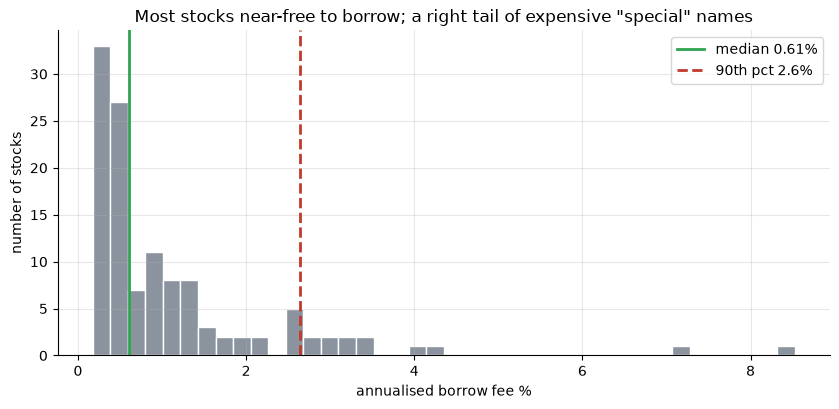

median 0.61%  90th pct 2.6%  max 8.5%


In [2]:
fees = PANEL['borrow_fee']
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(fees, bins=40, color=GREY, edgecolor='white')
ax.axvline(fees.median(), c=GREEN, lw=2, label=f'median {fees.median():.2f}%')
ax.axvline(np.percentile(fees,90), c=RED, lw=2, ls='--', label=f'90th pct {np.percentile(fees,90):.1f}%')
ax.set_xlabel('annualised borrow fee %'); ax.set_ylabel('number of stocks')
ax.set_title('Most stocks near-free to borrow; a right tail of expensive "special" names')
ax.legend(); plt.tight_layout(); plt.show()
print(f'median {fees.median():.2f}%  90th pct {np.percentile(fees,90):.1f}%  max {fees.max():.1f}%')

That's the real shape of the lending market: a big pile of general-collateral names you can borrow for almost nothing, and a thin, expensive tail of hard-to-borrow names.

**Now the main event — did the cheap fifth beat the expensive fifth?**

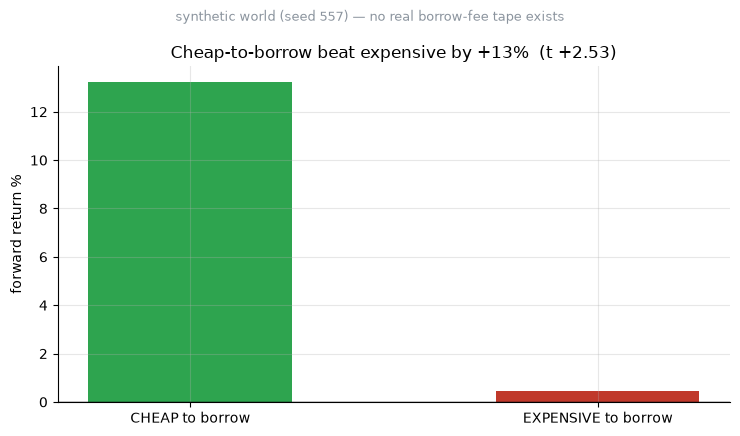

Cheap +13.2%  vs  Expensive +0.5%  ->  spread +12.8% (t +2.53)


In [3]:
b = st.bucket_returns(PANEL, 0.2); ls = st.long_short_tstat(b)
cheap_m, exp_m, spr, t = b['cheap_mean']*100, b['expensive_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['CHEAP to borrow','EXPENSIVE to borrow'], [cheap_m, exp_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Cheap-to-borrow beat expensive by {spr:+.0f}%  (t {t:+.2f})')
fig.suptitle('synthetic world (seed 557) — no real borrow-fee tape exists', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'Cheap +{cheap_m:.1f}%  vs  Expensive +{exp_m:.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')

There's the claim's sign: the **expensive-to-borrow** names (+0.5%) badly lagged the **cheap** ones (+13.2%), a **+12.8%** spread. The hard-to-borrow tail underperformed — exactly what the borrow-fee premium predicts.

**But is it just short interest wearing a fee costume?** Let's check whether the fee still matters once we hold short interest fixed:

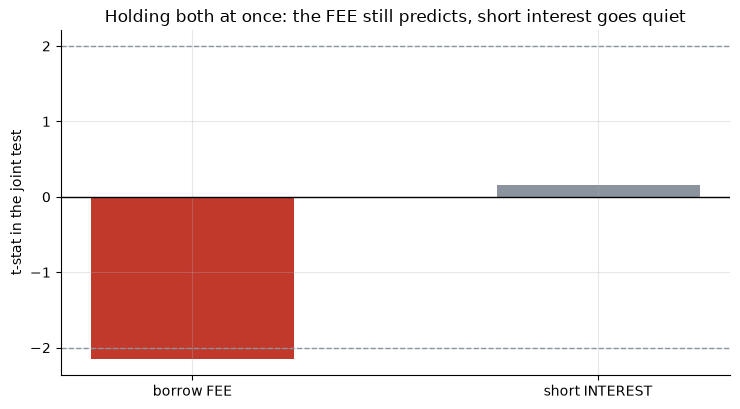

fee t -2.15  |  short-interest t +0.15


In [4]:
inc = st.incremental_regression(PANEL)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['borrow FEE','short INTEREST'], [inc['fee_t'], inc['si_t']],
       color=[RED if abs(inc['fee_t'])>=2 else AMBER, GREY], width=.5)
ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('t-stat in the joint test')
ax.set_title('Holding both at once: the FEE still predicts, short interest goes quiet')
plt.tight_layout(); plt.show()
print(f'fee t {inc["fee_t"]:+.2f}  |  short-interest t {inc["si_t"]:+.2f}')

When we let both compete, the **fee** keeps its punch (*t* -2.15) and short interest goes to noise (*t* +0.15). So the fee — the *price* of shorting — carries something the *quantity* shorted doesn't. That's the whole point: it's a different, arguably better signal than the one everyone watches.

## 5 · The verdict

- **Signal — Weak.** The effect is real *in our world* (spread +12.8%, *t* +2.53) and survives short interest — but there's **no free real tape** to confirm it, and even here it's modest. Real data would be needed to earn anything stronger.
- **Tradability — Fragile.** The alpha sits on the expensive-to-borrow short leg — the fee is both the signal *and* the rent. It survives at modest fees; the real hard-to-borrow tail would swamp it.
- **Distinct from short interest? — Yes.** The fee predicts *beyond* how heavily a stock is shorted.

## 6 · Could you actually trade it?

This is the trap that makes the fee signal so hard to harvest. The trade is *long the cheap names, short the expensive ones* — but the 'expensive' names are literally the ones that cost the most to borrow. The very fee that tells you to short them is the bill you pay to do it. On our modest synthetic fees it still nets out positive; but a real hard-to-borrow name can cost 20%, 50%, 100%+ a year to short — and that eats a 12% edge for breakfast. The alpha and the cost are the *same variable*.

## 7 · Going further 🚪

- **The neighbour.** [Study 262 — Short-Interest](../../262-short-interest/) sorts on the *quantity* shorted (short-% of float). This study sorts on the *price* (the fee) — and finds the price carries more.
- **The missing piece is data.** With a real borrow-fee tape (Markit / S3 Partners) and a full cycle you could finally certify this on the actual market. Until then it's a well-supported *Weak*.

*Have access to a real fee tape? Fork this, drop in the real panel, and show the cheap-minus-expensive spread clearing t = 2 on live data — that would flip Weak to Real.*